In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
retail = pd.read_csv('/content/OnlineRetail.csv', encoding='latin1')

print(retail.shape)

retail.head()

(541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [3]:
retail.tail()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12/9/2011 12:50,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/9/2011 12:50,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/2011 12:50,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/2011 12:50,4.15,12680.0,France
541908,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,12/9/2011 12:50,4.95,12680.0,France


In [4]:
retail.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


The dataset contains 541,909 transaction rows across 8 columns, covering real retail purchases from a UK-based online store between 2010 and 2011. Each row represents a single line item from an invoice, not a complete order. This means one customer visit can generate multiple rows, one per product purchased.

# Clean the Data

In [5]:
# Convertion of InvoiceDate to datetime
retail['InvoiceDate'] = pd.to_datetime(retail['InvoiceDate'])

# Droping rows with missing CustomerID
# CustomerID is the most critical column and has 135,080 missing values,
# meaning 25% of all transactions have no customer identifier.
# These rows cannot be assigned to any customer and must be dropped entirely before building customer-level features.
# The customer that cannot be identify cannot be segment
retail = retail.dropna(subset=['CustomerID'])

# Remove cancelled invoices (InvoiceNo starting with C)
retail = retail[~retail['InvoiceNo'].astype(str).str.startswith('C')]

# Remove negative or zero Quantity
# Quantity is stored as an integer and can contain negative values.
# Negative quantities represent returned or cancelled items and must be removed
# before calculating monetary value.
retail = retail[retail['Quantity'] > 0]

# Remove zero or negative UnitPrice
# UnitPrice is stored as a float. Some unit prices may be zero or negative,
# representing adjustments or errors that need filtering.
retail = retail[retail['UnitPrice'] > 0]

# Convertion CustomerID to integer
retail['CustomerID'] = retail['CustomerID'].astype(int)

# Total Price column created which needed for Monetary calculation
retail['TotalPrice'] = retail['Quantity'] * retail['UnitPrice']

In [6]:
# To confirm clean data
retail.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,0
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,0
Country,0
TotalPrice,0


In [7]:
retail['CustomerID'].nunique()

4338

In [8]:
print(retail.shape)

(397884, 9)


In [9]:
retail.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID,TotalPrice
count,397884.000000,397884,397884.000000,397884.000000,397884.000000
mean,12.988238,2011-07-10 23:41:23.511023360,3.116488,15294.423453,22.397000
min,1.000000,2010-12-01 08:26:00,0.001000,12346.000000,0.001000
25%,2.000000,2011-04-07 11:12:00,1.250000,13969.000000,4.680000
50%,6.000000,2011-07-31 14:39:00,1.950000,15159.000000,11.800000
75%,12.000000,2011-10-20 14:33:00,3.750000,16795.000000,19.800000
max,80995.000000,2011-12-09 12:50:00,8142.750000,18287.000000,168469.600000
std,179.331775,NaN,22.097877,1713.141560,309.071041


The dataset reduced from 541,909 rows to 397,884 rows after removing missing CustomerIDs, cancelled invoices, negative quantities, and zero unit prices. That is a reduction of 144,025 rows, approximately 26.6% of the original data. All 9 columns now show zero missing values, shows the cleaning pipeline worked correctly. The TotalPrice column was successfully created by multiplying Quantity by UnitPrice.

# Engineer RFM Features

In [10]:
# Set reference date one day after the last transaction
reference_date = retail['InvoiceDate'].max() + pd.Timedelta(days=1)
print(f"Reference date: {reference_date}")

Reference date: 2011-12-10 12:50:00


In [11]:
# Build RFM table at customer level
rfm = retail.groupby('CustomerID').agg(
    Recency=('InvoiceDate', lambda x: (reference_date - x.max()).days),
    Frequency=('InvoiceNo', 'nunique'),
    Monetary=('TotalPrice', 'sum')
).reset_index()

print(f"\nRFM Table Shape: {rfm.shape}")

rfm.head()


RFM Table Shape: (4338, 4)


,CustomerID,Recency,Frequency,Monetary
0,12346,326,1,77183.60
1,12347,2,7,4310.00
2,12348,75,4,1797.24
3,12349,19,1,1757.55
4,12350,310,1,334.40


In [12]:
rfm.describe()

,CustomerID,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000,4338.000000
mean,15300.408022,92.536422,4.272015,2054.266460
std,1721.808492,100.014169,7.697998,8989.230441
min,12346.000000,1.000000,1.000000,3.750000
25%,13813.250000,18.000000,1.000000,307.415000
50%,15299.500000,51.000000,2.000000,674.485000
75%,16778.750000,142.000000,5.000000,1661.740000
max,18287.000000,374.000000,209.000000,280206.020000


In [13]:
# Engineer additional behavioral features to reach 20+ columns
customer_features = retail.groupby('CustomerID').agg(
    Recency=('InvoiceDate', lambda x: (reference_date - x.max()).days),
    Frequency=('InvoiceNo', 'nunique'),
    Monetary=('TotalPrice', 'sum'),
    AvgOrderValue=('TotalPrice', 'mean'),
    TotalQuantity=('Quantity', 'sum'),
    AvgQuantityPerOrder=('Quantity', 'mean'),
    UniqueProducts=('StockCode', 'nunique'),
    AvgUnitPrice=('UnitPrice', 'mean'),
    MaxSingleTransaction=('TotalPrice', 'max'),
    MinSingleTransaction=('TotalPrice', 'min'),
    StdOrderValue=('TotalPrice', 'std'),
    TotalTransactionLines=('InvoiceNo', 'count'),
    UniqueInvoiceDays=('InvoiceDate', lambda x: x.dt.date.nunique()),
    FirstPurchaseDays=('InvoiceDate', lambda x: (reference_date - x.min()).days),
    PurchaseSpan=('InvoiceDate', lambda x: (x.max() - x.min()).days),
).reset_index()

# Fill NaN in StdOrderValue for customers with only one transaction
customer_features['StdOrderValue'] = customer_features['StdOrderValue'].fillna(0)

# Engineer derived features
customer_features['AvgDaysBetweenPurchases'] = (
    customer_features['PurchaseSpan'] / customer_features['Frequency']
).replace([np.inf, np.nan], 0)

customer_features['RevenuePerProduct'] = (
    customer_features['Monetary'] / customer_features['UniqueProducts']
)

customer_features['OrderValueGrowth'] = (
    customer_features['MaxSingleTransaction'] - customer_features['MinSingleTransaction']
)

customer_features['PurchaseConsistency'] = (
    customer_features['UniqueInvoiceDays'] / customer_features['Frequency']
)

print(f"\nFinal Feature Table Shape: {customer_features.shape}")
print(f"Total features: {customer_features.shape[1] - 1} (excluding CustomerID)")
print(customer_features.head())


Final Feature Table Shape: (4338, 20)
Total features: 19 (excluding CustomerID)
   CustomerID  Recency  Frequency  Monetary  AvgOrderValue  TotalQuantity  \
0       12346      326          1  77183.60   77183.600000          74215   
1       12347        2          7   4310.00      23.681319           2458   
2       12348       75          4   1797.24      57.975484           2341   
3       12349       19          1   1757.55      24.076027            631   
4       12350      310          1    334.40      19.670588            197   

   AvgQuantityPerOrder  UniqueProducts  AvgUnitPrice  MaxSingleTransaction  \
0         74215.000000               1      1.040000               77183.6   
1            13.505495             103      2.644011                 249.6   
2            75.516129              22      5.764839                 240.0   
3             8.643836              73      8.289041                 300.0   
4            11.588235              17      3.841176              

# Log Transform Then Scale

In [14]:
from sklearn.preprocessing import StandardScaler
import numpy as np

# Drop CustomerID before scaling
X = customer_features.drop(columns=['CustomerID'])

# Apply log1p transformation to skewed columns
# log1p handles zero values safely (log(0+1) = 0)
skewed_cols = [
    'Recency', 'Frequency', 'Monetary', 'AvgOrderValue',
    'TotalQuantity', 'AvgQuantityPerOrder', 'UniqueProducts',
    'MaxSingleTransaction', 'MinSingleTransaction', 'StdOrderValue',
    'TotalTransactionLines', 'UniqueInvoiceDays', 'FirstPurchaseDays',
    'PurchaseSpan', 'AvgDaysBetweenPurchases', 'RevenuePerProduct',
    'OrderValueGrowth'
]

X_log = X.copy()
for col in skewed_cols:
    X_log[col] = np.log1p(X_log[col])

# Scale all features to mean=0, std=1
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_log)

print(X_scaled.shape)
print(X_scaled.mean(axis=0).round(4))
print(X_scaled.std(axis=0).round(4))

(4338, 19)
[-0. -0.  0.  0.  0. -0.  0. -0. -0. -0. -0. -0.  0.  0. -0.  0. -0. -0.
  0.]
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


 # Findings
 The shape of 4,338 rows and 19 features matches exactly what we expect, one row per customer and 19 behavioural features ready for PCA.

 The mean array shows values of 0 or negative 0 across all 19 features. Negative 0 and positive 0 are mathematically identical. StandardScaler successfully centred every feature around zero, meaning no single feature will dominate PCA due to a higher average value.

 The extreme values like Customer 12346's 77,183.60 monetary spend are now compressed into a range comparable to other customers, preventing outliers from pulling cluster centroids away from the true customer groupings.


# Apply Principal Component Analysis (PCA)

In [15]:
from sklearn.decomposition import PCA

# it was First fit PCA with all 19 components to see explained variance
pca_full = PCA(random_state=42)
pca_full.fit(X_scaled)

# To Calculate cumulative explained variance
explained_variance = pca_full.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

print("Explained variance per component:")
for i, (ev, cv) in enumerate(zip(explained_variance, cumulative_variance)):
    print(f"PC{i+1}: {ev:.4f} ({ev*100:.2f}%) | Cumulative: {cv*100:.2f}%")

Explained variance per component:
PC1: 0.3993 (39.93%) | Cumulative: 39.93%
PC2: 0.2557 (25.57%) | Cumulative: 65.50%
PC3: 0.0771 (7.71%) | Cumulative: 73.21%
PC4: 0.0612 (6.12%) | Cumulative: 79.33%
PC5: 0.0551 (5.51%) | Cumulative: 84.85%
PC6: 0.0494 (4.94%) | Cumulative: 89.78%
PC7: 0.0388 (3.88%) | Cumulative: 93.66%
PC8: 0.0258 (2.58%) | Cumulative: 96.24%
PC9: 0.0148 (1.48%) | Cumulative: 97.71%
PC10: 0.0080 (0.80%) | Cumulative: 98.52%
PC11: 0.0077 (0.77%) | Cumulative: 99.28%
PC12: 0.0052 (0.52%) | Cumulative: 99.81%
PC13: 0.0012 (0.12%) | Cumulative: 99.93%
PC14: 0.0005 (0.05%) | Cumulative: 99.98%
PC15: 0.0001 (0.01%) | Cumulative: 99.99%
PC16: 0.0000 (0.00%) | Cumulative: 99.99%
PC17: 0.0000 (0.00%) | Cumulative: 100.00%
PC18: 0.0000 (0.00%) | Cumulative: 100.00%
PC19: 0.0000 (0.00%) | Cumulative: 100.00%


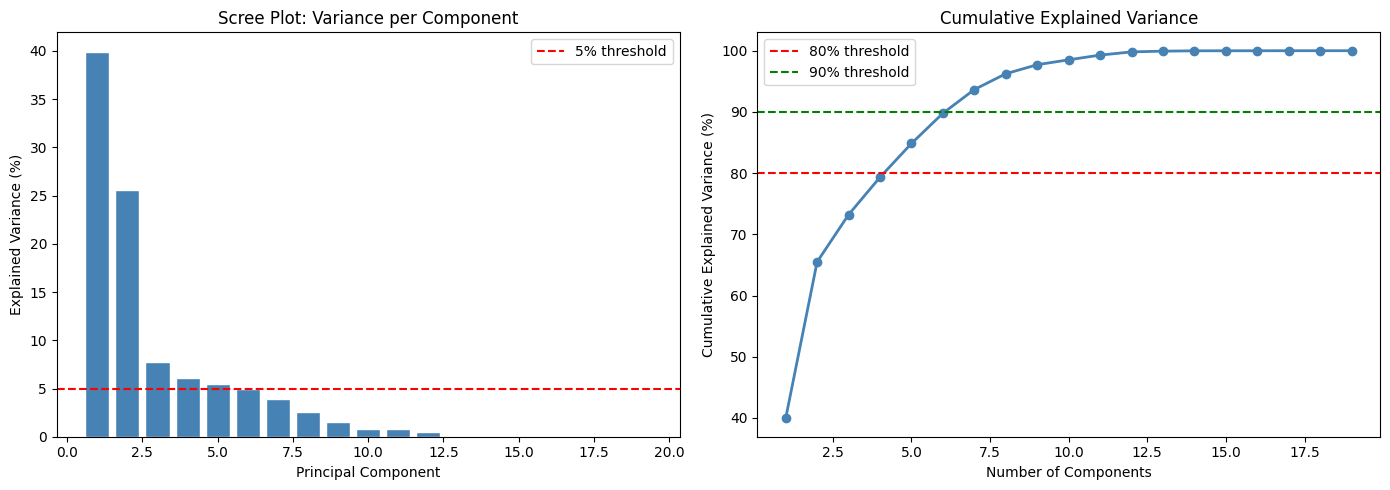

In [16]:
# Plot explained variance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scree plot
axes[0].bar(range(1, len(explained_variance)+1),
            explained_variance * 100,
            color='steelblue', edgecolor='white')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance (%)')
axes[0].set_title('Scree Plot: Variance per Component')
axes[0].axhline(y=5, color='red', linestyle='--', label='5% threshold')
axes[0].legend()

# Cumulative variance plot
axes[1].plot(range(1, len(cumulative_variance)+1),
             cumulative_variance * 100,
             marker='o', color='steelblue', linewidth=2)
axes[1].axhline(y=80, color='red', linestyle='--', label='80% threshold')
axes[1].axhline(y=90, color='green', linestyle='--', label='90% threshold')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Explained Variance (%)')
axes[1].set_title('Cumulative Explained Variance')
axes[1].legend()

plt.tight_layout()
plt.show()

# Scree Plot Interpretation

The scree plot shows a dramatic drop after the first two principal components. PC1 alone captures 39.93% of all customer variation, the single largest source of behavioural difference across all 4,338 customers. PC2 adds another 25.57%, bringing the two-component total to 65.50%. After PC2, the bars drop sharply below the 5% threshold red line starting from PC6 onward. This sharp elbow between PC2 and PC3 is the classic scree plot signal that the first two components carry the dominant structure in the data. Everything after PC6 contributes less than 5% individually and represents noise or minor behavioural nuances rather than meaningful customer differences.

# Cumulative Variance Interpretation
The cumulative variance chart confirms the decision precisely. Five components are needed to cross the 80% threshold, reaching 84.85% explained variance. Seven components are needed to cross the 90% threshold, reaching 93.66%. Beyond component 12, the curve flattens completely and the remaining components add almost nothing, with PC16 through PC19 each contributing 0.00% of additional variance. This means those last four components are essentially mathematical noise with no real information content.

In [17]:
# To find how many components explain 80% and 90% variance
components_80 = np.argmax(cumulative_variance >= 0.80) + 1
components_90 = np.argmax(cumulative_variance >= 0.90) + 1

print(f"Components needed for 80% variance: {components_80}")
print(f"Components needed for 90% variance: {components_90}")

Components needed for 80% variance: 5
Components needed for 90% variance: 7


For this project we will use all three strategically. Use 7 components for KMeans clustering to preserve 93.66% of customer information, then use 2 components purely for visualising the clusters in a 2D scatter plot. This is the professional approach, cluster in higher dimensions for accuracy, visualise in 2D for communication.

# Apply PCA and Run Elbow Method

In [18]:
# Apply PCA with 7 components for clustering
pca_7 = PCA(n_components=7, random_state=42)
X_pca_7 = pca_7.fit_transform(X_scaled)

# Apply PCA with 2 components for visualisation only
pca_2 = PCA(n_components=2, random_state=42)
X_pca_2 = pca_2.fit_transform(X_scaled)

print(f"PCA 7-component shape: {X_pca_7.shape}")
print(f"PCA 2-component shape: {X_pca_2.shape}")
print(f"Variance retained (7 components): {pca_7.explained_variance_ratio_.sum()*100:.2f}%")
print(f"Variance retained (2 components): {pca_2.explained_variance_ratio_.sum()*100:.2f}%")

PCA 7-component shape: (4338, 7)
PCA 2-component shape: (4338, 2)
Variance retained (7 components): 93.66%
Variance retained (2 components): 65.50%


# Interpretation

PCA Results
The 7-component PCA successfully compressed 4,338 customers from 19 original features into 7 principal components while retaining 93.66% of all customer behavioural information. Only 6.34% of information was sacrificed in exchange for a dramatically simpler representation. The 2-component version retains 65.50% and will be used purely for visualisation later. Clustering will happen in the 7-component space where the data is more faithfully represented.

In [19]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Elbow Method: test K from 2 to 10
inertia_values = []
silhouette_values = []
k_range = range(2, 11)

print("Testing K values...")
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_pca_7)
    inertia_values.append(kmeans.inertia_)
    silhouette_values.append(silhouette_score(X_pca_7, labels))
    print(f"K={k} | Inertia: {kmeans.inertia_:.2f} | Silhouette: {silhouette_score(X_pca_7, labels):.4f}")

Testing K values...
K=2 | Inertia: 54615.99 | Silhouette: 0.3007
K=3 | Inertia: 45941.23 | Silhouette: 0.2779
K=4 | Inertia: 40466.44 | Silhouette: 0.2496
K=5 | Inertia: 36957.88 | Silhouette: 0.2498
K=6 | Inertia: 33936.60 | Silhouette: 0.2099
K=7 | Inertia: 31245.20 | Silhouette: 0.2408
K=8 | Inertia: 28856.74 | Silhouette: 0.2234
K=9 | Inertia: 26803.62 | Silhouette: 0.2218
K=10 | Inertia: 25321.16 | Silhouette: 0.2235


#Silhouette Score Interpretation
The silhouette score tells a clearer story. K=2 produces the highest score of 0.3007, meaning two broad clusters are the most mathematically well-separated groupings in this data. K=3 drops to 0.2779, still reasonable. K=4 and K=5 are nearly identical at 0.2496 and 0.2498 respectively, suggesting these two options produce clusters of similar quality. K=6 hits the lowest point at 0.2099, meaning 6 clusters overlap more than any other option tested. K=7 recovers slightly to 0.2408 before declining again. From K=8 onward, scores stabilise around 0.22 to 0.22, indicating no further improvement.


# Interpretation


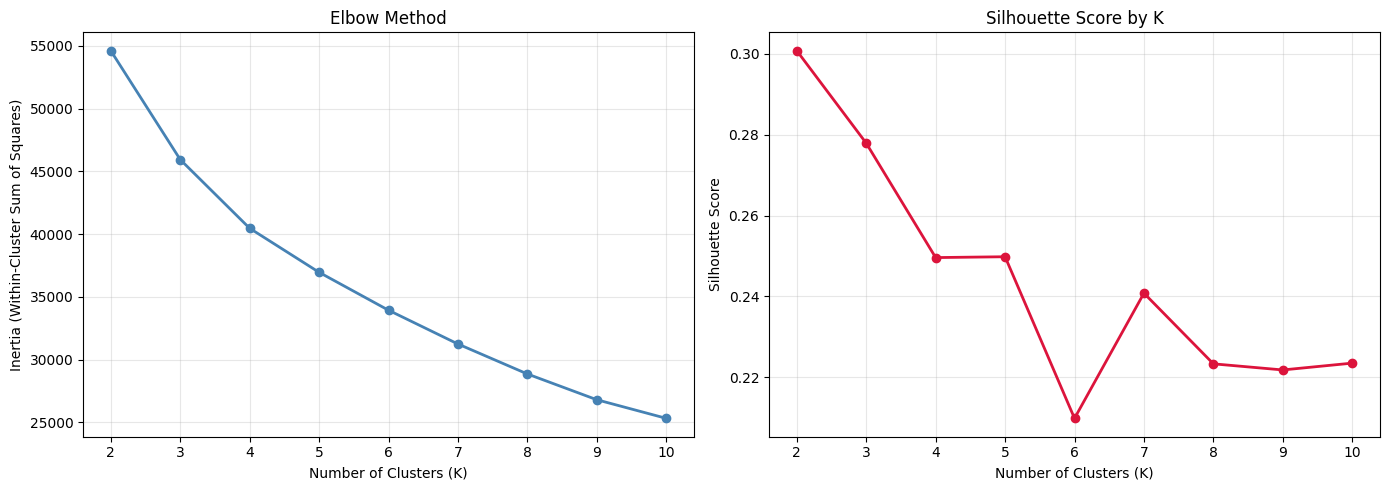

In [20]:
# Plot Elbow Method and Silhouette Scores
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow plot
axes[0].plot(k_range, inertia_values, marker='o',
             color='steelblue', linewidth=2)
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia (Within-Cluster Sum of Squares)')
axes[0].set_title('Elbow Method')
axes[0].grid(alpha=0.3)

# Silhouette score plot
axes[1].plot(k_range, silhouette_values, marker='o',
             color='crimson', linewidth=2)
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score by K')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

The elbow plot shows inertia dropping steeply from K=2 (54,615) to K=3 (45,941) to K=4 (40,466). After K=4, the rate of decline slows noticeably. From K=4 to K=5 the drop is 3,508 points. From K=5 to K=6 it is 3,021 points. From K=6 onward the drops become progressively smaller and the curve flattens into a gentle slope rather than a sharp descent. The elbow is not a perfectly sharp bend in this dataset, which is common with real-world retail data, but the transition from steep to gradual decline points to K=4 or K=5 as the zone where adding more clusters stops delivering meaningful separation gains.

I choose to use K=3 . Based on the reasons.

Since the project is about customer segmentation using PCA and K-Means, K = 3 is the strongest choice.
Reasons:
It is close to the elbow point where improvements begin to level off.
It maintains a relatively high Silhouette Score (0.2779).
It produces more useful customer groups than K = 2.
It avoids overcomplicating the model with too many clusters.
The 2-component PCA is then used only to visualize these three clusters in a scatter plot.

# Train Final KMeans with K=3

In [21]:
# Train final KMeans model with K=3
kmeans_final = KMeans(n_clusters=3, random_state=42, n_init=10)
cluster_labels = kmeans_final.fit_predict(X_pca_7)

# Add cluster labels to customer features
customer_features['Cluster'] = cluster_labels

# Add 2D PCA coordinates for visualisation
customer_features['PC1'] = X_pca_2[:, 0]
customer_features['PC2'] = X_pca_2[:, 1]

# Check cluster sizes
print("Cluster Distribution:")
print(customer_features['Cluster'].value_counts().sort_index())
print(f"\nSilhouette Score (K=3): {silhouette_score(X_pca_7, cluster_labels):.4f}")

Cluster Distribution:
Cluster
0     649
1    1973
2    1716
Name: count, dtype: int64

Silhouette Score (K=3): 0.2779


#Cluster Distribution
The 4,338 customers split into three groups. Cluster 1 is the largest with 1,973 customers (45.5%), Cluster 2 contains 1,716 customers (39.6%), and Cluster 0 is the smallest with 649 customers (15.0%). No cluster is excessively small or dominant, confirming K=3 produces a balanced and meaningful segmentation. The silhouette score of 0.2779 confirms these three clusters are reasonably well separated given the complexity of real-world retail behaviour.

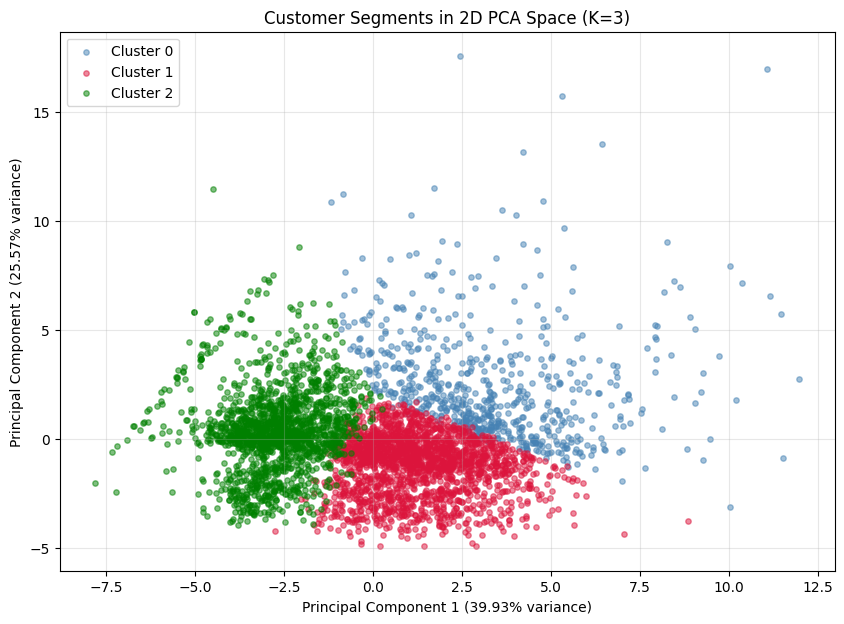

In [22]:
# Visualise clusters in 2D PCA space
plt.figure(figsize=(10, 7))
colors = ['steelblue', 'crimson', 'green']
labels = ['Cluster 0', 'Cluster 1', 'Cluster 2']

for cluster, color, label in zip(range(3), colors, labels):
    mask = customer_features['Cluster'] == cluster
    plt.scatter(
        customer_features.loc[mask, 'PC1'],
        customer_features.loc[mask, 'PC2'],
        c=color, label=label, alpha=0.5, s=15
    )

plt.xlabel('Principal Component 1 (39.93% variance)')
plt.ylabel('Principal Component 2 (25.57% variance)')
plt.title('Customer Segments in 2D PCA Space (K=3)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# 2D PCA Scatter Plot Interpretation
The scatter plot shows three visually distinct regions across the two principal component axes. Cluster 0 (steelblue) occupies the upper right region of the chart, spreading along both positive PC1 and positive PC2 directions. This positioning means these customers score high on the behavioural dimensions that PC1 and PC2 represent, which based on your feature set corresponds to high transaction volume and high spending patterns. Cluster 1 (crimson) sits in the lower centre and right of the chart, concentrated along positive PC1 but negative PC2. These customers have moderate to high PC1 scores but lower PC2 scores, suggesting high frequency but lower average order values. Cluster 2 (green) occupies the left side of the chart, concentrated around negative PC1 values, indicating customers with lower overall transaction activity. The three clusters overlap somewhat in the centre of the plot, which is expected since the visualisation uses only 65.50% of the total variance. The true separation in 7-dimensional PCA space is stronger than what this 2D projection shows.

In [23]:
# Analyse cluster profiles using original RFM features
cluster_profile = customer_features.groupby('Cluster')[
    ['Recency', 'Frequency', 'Monetary',
     'AvgOrderValue', 'UniqueProducts',
     'PurchaseSpan', 'AvgDaysBetweenPurchases']
].mean().round(2)

print("Cluster Profiles (Mean Values):")
print(cluster_profile)

Cluster Profiles (Mean Values):
         Recency  Frequency  Monetary  AvgOrderValue  UniqueProducts  \
Cluster                                                                
0          54.83      10.00   7987.56         335.70           75.33   
1          53.99       5.09   1609.32          15.22           91.83   
2         151.12       1.17    321.85          28.33           21.40   

         PurchaseSpan  AvgDaysBetweenPurchases  
Cluster                                         
0              221.41                    35.29  
1              207.36                    52.11  
2                7.61                     3.67  


#Cluster Profile Interpretation
The cluster profile table is where the real business story emerges.
Cluster 0 is your most valuable customer group. With an average monetary spend of 7,987.56, a frequency of 10 orders, and a purchase span of 221 days, these 649 customers are highly engaged, long-term, high-spending buyers. Their average order value of 335.70 is dramatically higher than the other two clusters, and they purchase across 75 unique products on average. Despite having a recency of 54.83 days, comparable to Cluster 1, their overall engagement depth makes them the clear Champions of your customer base.
Cluster 1 is your mid-tier active customer group. With 1,973 customers, this is your largest segment. They spend an average of 1,609.32, order 5 times on average, and browse the widest product range at 91.83 unique products. Their average order value of just 15.22 is the lowest of all three clusters, suggesting they buy many small, low-cost items across a broad catalogue. Their purchase span of 207 days shows sustained engagement over time. These are your Loyal Regular Buyers who are actively engaged but spending modestly per transaction.
Cluster 2 is your inactive or lapsed customer group. With a recency of 151.12 days, these 1,716 customers have not purchased in roughly five months. Their frequency of just 1.17 orders and monetary spend of 321.85 confirm they are mostly one-time or very infrequent buyers. Their purchase span of only 7.61 days and average days between purchases of 3.67 reveals that on the rare occasions they did buy, purchases were clustered together in a very short window before they disappeared entirely. These are your At Risk or Lost Customers who need re-engagement campaigns.

# Assign Business Personas

In [28]:
# Map cluster numbers to business personas
persona_map = {
    0: 'Champion Customers',
    1: 'Loyal Regular Customers',
    2: 'At Risk / Lapsed Customers'
}

customer_features['Persona'] = customer_features['Cluster'].map(persona_map)

# Persona distribution
print("Persona Distribution:")
print(customer_features['Persona'].value_counts())


Persona Distribution:
Persona
Loyal Regular Customers       1973
At Risk / Lapsed Customers    1716
Champion Customers             649
Name: count, dtype: int64


# Persona Distribution
The 4,338 customers are now assigned to three clearly defined business personas. Loyal Regular Customers form the largest group with 1,973 customers representing 45.5% of the base. At Risk and Lapsed Customers follow closely with 1,716 customers at 39.6%. Champion Customers are the smallest but most valuable group with just 649 customers at 15.0% of the total base.

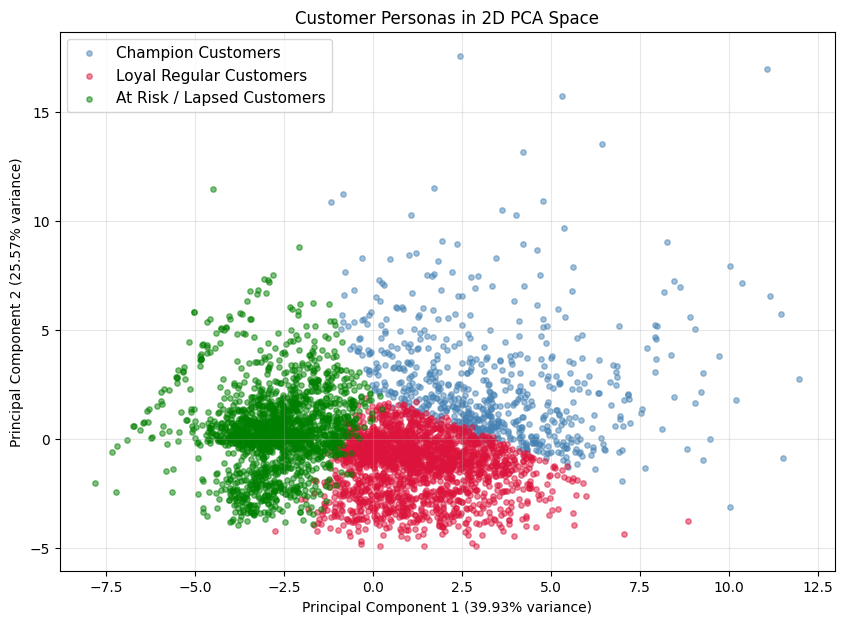

In [29]:
# Visualise personas
plt.figure(figsize=(10, 7))
colors = {'Champion Customers': 'steelblue',
          'Loyal Regular Customers': 'crimson',
          'At Risk / Lapsed Customers': 'green'}

for persona, color in colors.items():
    mask = customer_features['Persona'] == persona
    plt.scatter(
        customer_features.loc[mask, 'PC1'],
        customer_features.loc[mask, 'PC2'],
        c=color, label=persona, alpha=0.5, s=15
    )

plt.xlabel('Principal Component 1 (39.93% variance)')
plt.ylabel('Principal Component 2 (25.57% variance)')
plt.title('Customer Personas in 2D PCA Space')
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.show()

# Scatter Plot Interpretation
The persona scatter plot is identical in structure to the cluster plot but now carries business meaning in the labels. Champion Customers (steelblue) occupy the upper right quadrant, visually separated from the other two groups along both principal component axes. Their spread into high positive PC1 and PC2 territory confirms they are the most behaviourally distinct customers in the dataset. Loyal Regular Customers (crimson) dominate the centre and lower right of the chart, tightly clustered along the PC1 axis with slightly negative PC2 values. At Risk and Lapsed Customers (green) are concentrated on the left side with negative PC1 values, confirming their low engagement scores across the behavioural dimensions captured by the first principal component.

In [30]:
# Final persona profile summary
print("\nPersona Summary:")
print(customer_features.groupby('Persona')[
    ['Recency', 'Frequency', 'Monetary', 'AvgOrderValue', 'UniqueProducts']
].mean().round(2))


Persona Summary:
                            Recency  Frequency  Monetary  AvgOrderValue  \
Persona                                                                   
At Risk / Lapsed Customers   151.12       1.17    321.85          28.33   
Champion Customers            54.83      10.00   7987.56         335.70   
Loyal Regular Customers       53.99       5.09   1609.32          15.22   

                            UniqueProducts  
Persona                                     
At Risk / Lapsed Customers           21.40  
Champion Customers                   75.33  
Loyal Regular Customers              91.83  


#Persona Summary Interpretation
Champion Customers are the top 15% and the most critical business asset. They spend an average of 7,987.56, order 10 times per year, and engage across 75 unique products. Their average order value of 335.70 is 22 times higher than Loyal Regular Customers and nearly 12 times higher than At Risk customers. Their recency of 54.83 days shows they are still active and engaged. These customers generate disproportionate revenue and must be protected with premium loyalty programs, early access to new products, and personalised account management. Losing even a fraction of this group would have an outsized negative impact on total revenue.

Loyal Regular Customers are the growth engine. With 1,973 customers and an average spend of 1,609.32 per year across 5 orders, this group represents stable, predictable revenue. Their product breadth of 91.83 unique products is actually the highest of all three segments, meaning they explore the catalogue more broadly than even Champions. Their average order value of just 15.22 reveals they buy frequently but in small quantities, typical of customers purchasing low-cost everyday items regularly. The business opportunity here is clear. If even 10% of this group can be moved into Champion territory through targeted upselling, cross-selling, or bundle offers, the revenue impact would be significant given the group's size.

At Risk and Lapsed Customers represent the biggest retention challenge. With 1,716 customers who last purchased an average of 151.12 days ago, roughly five months, this group is dangerously close to being permanently lost. Their frequency of just 1.17 orders and total spend of 321.85 confirms most of them made a single purchase and never returned. Their purchase span of only 7.61 days means their entire shopping history with this retailer lasted less than two weeks. Without intervention, the majority of these customers will churn permanently. Win-back campaigns with time-limited discount offers, personalised email reminders referencing their previous purchases, or low-barrier reactivation incentives are the most appropriate strategies for this segment.

# To Save the Model

In [31]:
import joblib
import json

# Save KMeans model
joblib.dump(kmeans_final, 'kmeans_customer_segmentation.pkl')

# Save PCA models
joblib.dump(pca_7, 'pca_7_components.pkl')
joblib.dump(pca_2, 'pca_2_components.pkl')

# Save scaler
joblib.dump(scaler, 'customer_scaler.pkl')

# Save persona mapping
persona_map_export = {
    "0": "Champions",
    "1": "Loyal Regular Customers",
    "2": "At Risk / Lapsed Customers"
}

with open('persona_map.json', 'w') as f:
    json.dump(persona_map_export, f)

# Save final customer segments to CSV
customer_features.to_csv('customer_segments.csv', index=False)

print("All models and files saved successfully")
print("\nFiles saved:")
print("  kmeans_customer_segmentation.pkl")
print("  pca_7_components.pkl")
print("  pca_2_components.pkl")
print("  customer_scaler.pkl")
print("  persona_map.json")
print("  customer_segments.csv")

# Download all files
from google.colab import files
files.download('kmeans_customer_segmentation.pkl')
files.download('pca_7_components.pkl')
files.download('pca_2_components.pkl')
files.download('customer_scaler.pkl')
files.download('persona_map.json')
files.download('customer_segments.csv')

All models and files saved successfully

Files saved:
  kmeans_customer_segmentation.pkl
  pca_7_components.pkl
  pca_2_components.pkl
  customer_scaler.pkl
  persona_map.json
  customer_segments.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>